# Description

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV624"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv624')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv624/lv624-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV624,gene_band
0,SOCS6,4.326932,18q22.2
1,B3GNT5,3.702558,3q27.1
2,SLC2A5,3.454996,1p36.23
3,ZNF254,3.206303,19p12
4,OLR1,2.682578,12p13.2
5,RUNX2,2.369068,6p21.1
6,C3AR1,2.318417,12p13.31
7,CCR5,2.167354,3p21.31
8,CD302,2.143682,2q24.2
9,ST8SIA4,2.129903,5q21.1


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-01-29 20:50:16,634 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-01-29 20:50:16,635 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP057196, SRP042161, SRP055569, SRP064454, SRP013363, SRP066834, SRP060416, SRP050499, SRP045352, SRP043033, SRP064735, SRP052491, SRP055153, SRP005279, SRP057852, SRP058773, SRP042043, SRP058237, SRP059379, SRP010644, SRP039361, SRP027383, SRP012461, SRP041826, SRP064464, SRP033135, SRP024268, SRP026052, SRP063840, SRP014542, SRP044756, SRP038761, SRP056197, SRP056295, SRP065445, SRP007359, SRP045569, SRP030617, SRP045545, SRP019222, SRP014213, SRP031459, SRP003754, SRP059035, SRP050272, SRP009247, SRP012015, SRP022892, SRP058667, SRP014428, SRP045565, SRP056049, SRP044286, SRP042186, SRP039397, SRP018838, SRP066152, SRP020470, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (57 != 58)
  warnings.warn(


In [12]:
lv_data.shape

(6844, 87)

In [13]:
lv_data.head()

tissue        cell type               age c1 chip id  \
project   run                                                                
SRP057196 SRR1975007  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   
          SRR1975008  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   
          SRR1975006  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   
          SRR1975005  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   
          SRR1975004  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   

                     experiment_sample_name cell line patient id subtype  \
project   run                                                              
SRP057196 SRR1975007                  FB_S6       NaN        NaN     NaN   
          SRR1975008                  FB_S6       NaN        NaN     NaN   
          SRR1975006                  FB_S6       NaN        NaN     NaN   
          SRR1975005                  FB_S6       NaN        NaN     NaN   
          SRR1975004                  FB_S6       NaN        NaN     NaN   

                     cell subtype cell line stably expressing  ... multiplex  \
project   run                                                  ...             
SRP057196 SRR1975007          NaN                         NaN  ...       NaN   
          SRR1975008          NaN                         NaN  ...       NaN   
          SRR1975006          NaN                         NaN  ...       NaN   
          SRR1975005          NaN                         NaN  ...       NaN   
          SRR1975004          NaN                         NaN  ...       NaN   

                     condition dynamic program knockdown labexpid genotype  \
project   run                                                                
SRP057196 SRR1975007       NaN             NaN       NaN      NaN      NaN   
          SRR1975008       NaN             NaN       NaN      NaN      NaN   
          SRR1975006       NaN             NaN       NaN      NaN      NaN   
          SRR1975005       NaN             NaN       NaN      NaN      NaN   
          SRR1975004       NaN             NaN       NaN      NaN      NaN   

                     subject id lactation stage extraction protocol     LV624  
project   run                                                                  
SRP057196 SRR1975007        NaN             NaN                 NaN  0.006163  
          SRR1975008        NaN             NaN                 NaN  0.074455  
          SRR1975006        NaN             NaN                 NaN  0.088311  
          SRR1975005        NaN             NaN                 NaN  0.146090  
          SRR1975004        NaN             NaN                 NaN  0.044701  

[5 rows x 87 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

c1 chip id                        0.149166
experiment_sample_name            0.149166
age                               0.134534
tissue                            0.038361
cell subtype                      0.034894
cell line stably expressing       0.027019
par-clip antibody                 0.027019
culture medium                    0.020569
cell type                         0.017847
sampling time                     0.010293
patient id                        0.005624
tonsil donor                      0.005490
facs gating                       0.005490
subtype                           0.004799
reprogramming time point (day)    0.004283
well number                       0.004283
Stage                             0.004077
reprogramming vector              0.003827
iPSc                              0.003827
disease state                     0.003780
dtype: float64

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

tissue            0.038361
cell subtype      0.034894
cell type         0.017847
cell line         0.002787
tissue subtype    0.001914
tissue type       0.001914
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [16]:
lv_attrs_selected = [
    "tissue",
    "cell subtype",
    "cell type",
]

In [17]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [18]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [19]:
_tmp_seq[0]

tissue  \
project   run                                                             
SRP057196 SRR1974598                                        hippocampus   
          SRR1974606                                             cortex   
          SRR1974596                                        hippocampus   
          SRR1974599                                        hippocampus   
SRP042161 SRR1294911                                                NaN   
          SRR1295103                                                NaN   
SRP055569 SRR1821527                                                NaN   
SRP057196 SRR1974868                                             cortex   
          SRR1974591                                        hippocampus   
          SRR1974666                                             cortex   
SRP064454 SRR2557119                                                NaN   
SRP057196 SRR1974581                                        hippocampus   
          SRR1974668                                             cortex   
SRP064454 SRR2557121                                                NaN   
SRP057196 SRR1974669                                             cortex   
SRP064454 SRR2557120                                                NaN   
SRP057196 SRR1974582                                        hippocampus   
          SRR1974749                                             cortex   
          SRR1974595                                        hippocampus   
SRP013363 SRR500482                                                 NaN   
SRP066834 SRR2967492  Microdissected cortical-like ventricle from ce...   
          SRR2967666                                    Fetal neocortex   
SRP060416 SRR2088343                                                NaN   
SRP057196 SRR1974671                                             cortex   
SRP060416 SRR2088285                                                NaN   

                             cell subtype  \
project   run                               
SRP057196 SRR1974598                  NaN   
          SRR1974606                  NaN   
          SRR1974596                  NaN   
          SRR1974599                  NaN   
SRP042161 SRR1294911                  NaN   
          SRR1295103                  NaN   
SRP055569 SRR1821527                  NaN   
SRP057196 SRR1974868                  NaN   
          SRR1974591                  NaN   
          SRR1974666                  NaN   
SRP064454 SRR2557119  CD45 positive cells   
SRP057196 SRR1974581                  NaN   
          SRR1974668                  NaN   
SRP064454 SRR2557121  CD45 positive cells   
SRP057196 SRR1974669                  NaN   
SRP064454 SRR2557120  CD45 positive cells   
SRP057196 SRR1974582                  NaN   
          SRR1974749                  NaN   
          SRR1974595                  NaN   
SRP013363 SRR500482                   NaN   
SRP066834 SRR2967492                  NaN   
          SRR2967666                  NaN   
SRP060416 SRR2088343                  NaN   
SRP057196 SRR1974671                  NaN   
SRP060416 SRR2088285                  NaN   

                                                              cell type  \
project   run                                                             
SRP057196 SRR1974598                                          microglia   
          SRR1974606                                          microglia   
          SRR1974596                                                OPC   
          SRR1974599                                          microglia   
SRP042161 SRR1294911                                       Glioblastoma   
          SRR1295103                                       Glioblastoma   
SRP055569 SRR1821527  mixture of U87 human glioma cells and MCF10a h...   
SRP057196 SRR1974868                                          microglia   
          SRR1974591                                          microglia  

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [20]:
_tmp_seq[1]

tissue cell subtype  \
project   run                                        
SRP066834 SRR2967704  Fetal neocortex          NaN   
SRP057196 SRR1974552           cortex          NaN   
          SRR1974698           cortex          NaN   
SRP050499 SRR2013713              NaN          NaN   
SRP057196 SRR1974836           cortex          NaN   
SRP055569 SRR1821607              NaN          NaN   
          SRR1821385              NaN          NaN   
SRP057196 SRR1974548           cortex          NaN   
SRP066834 SRR2967772  Fetal neocortex          NaN   
SRP057196 SRR1974740           cortex          NaN   
SRP045352 SRR1539211              NaN          NaN   
SRP043033 SRR1363139              NaN          NaN   
SRP055569 SRR1821688              NaN          NaN   
SRP060416 SRR2088218              NaN          NaN   
          SRR2088236              NaN          NaN   
SRP064735 SRR2634935              NaN          NaN   
SRP042161 SRR1295241              NaN          NaN   
SRP064735 SRR2634934              NaN          NaN   
SRP055569 SRR1821475              NaN          NaN   
SRP057196 SRR1974807           cortex          NaN   
          SRR1974594      hippocampus          NaN   
          SRR1974593      hippocampus          NaN   
SRP052491 SRR1762738              NaN          NaN   
SRP060416 SRR2088274              NaN          NaN   
SRP064735 SRR2634933              NaN          NaN   

                                                              cell type  \
project   run                                                             
SRP066834 SRR2967704                                                NaN   
SRP057196 SRR1974552                                             hybrid   
          SRR1974698                                         astrocytes   
SRP050499 SRR2013713                                                NaN   
SRP057196 SRR1974836                                   oligodendrocytes   
SRP055569 SRR1821607  mixture of U87 human glioma cells and MCF10a h...   
          SRR1821385                             U87 human glioma cells   
SRP057196 SRR1974548                                   oligodendrocytes   
SRP066834 SRR2967772                                                NaN   
SRP057196 SRR1974740                                         astrocytes   
SRP045352 SRR1539211                                           monocyte   
SRP043033 SRR1363139                                   Macrophages(BC9)   
SRP055569 SRR1821688                   MCF10a human breast cancer cells   
SRP060416 SRR2088218                       tonsil Innate lymphoid cells   
          SRR2088236                       tonsil Innate lymphoid cells   
SRP064735 SRR2634935                                                NaN   
SRP042161 SRR1295241                             Gliomasphere Cell Line   
SRP064735 SRR2634934                                                NaN   
SRP055569 SRR1821475  mixture of U87 human glioma cells and MCF10a h...   
SRP057196 SRR1974807                                            neurons   
          SRR1974594                                                OPC   
          SRR1974593                                                OPC   
SRP052491 SRR1762738                alveolar macrophages from BAL fluid   
SRP060416 SRR2088274                       tonsil Innate lymphoid cells   
SRP064735 SRR2634933                                                NaN   

                         LV624  
project   run                   
SRP066834 SRR2967704  0.355703  
SRP057196 SRR1974552  0.350059  
          SRR1974698  0.340307  
SRP050499 SRR2013713  0.331789  
SRP057196 SRR1974836  0.327527  
SRP055569 SRR1821607  0.325180  
          SRR1821385  0.324903  
SRP057196 SRR1974548  0.323068  
SRP066834 SRR2967772  0.320248  
SRP057196 SRR1974740  0.310046  
SRP045352 SRR1539211  0.301539  
SRP043033 SRR1363139  0.292946  
SRP055569 SRR1821688  0.288825  
SRP060416 SRR2088218  0.283152  
          SRR20882

Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [21]:
# list the top 10 samples from this project
lv_data.loc[["SRP015360"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

KeyError: "['SRP015360'] not in index"

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [23]:
SELECTED_ATTRIBUTES = [
    "tissue",
    "cell subtype",
    "cell type",
]

## Get a single attribute with "cell type/tissue" information

In [24]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [25]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [26]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [27]:
plot_data.head(20)

tissue  \
project   run                                                             
SRP057196 SRR1974598                                        hippocampus   
          SRR1974606                                             cortex   
          SRR1974596                                        hippocampus   
          SRR1974599                                        hippocampus   
SRP042161 SRR1294911                                       Glioblastoma   
          SRR1295103                                       Glioblastoma   
SRP055569 SRR1821527  mixture of U87 human glioma cells and MCF10a h...   
SRP057196 SRR1974868                                             cortex   
          SRR1974591                                        hippocampus   
          SRR1974666                                             cortex   
SRP064454 SRR2557119                                CD45 positive cells   
SRP057196 SRR1974581                                        hippocampus   
          SRR1974668                                             cortex   
SRP064454 SRR2557121                                CD45 positive cells   
SRP057196 SRR1974669                                             cortex   
SRP064454 SRR2557120                                CD45 positive cells   
SRP057196 SRR1974582                                        hippocampus   
          SRR1974749                                             cortex   
          SRR1974595                                        hippocampus   
SRP013363 SRR500482                                     NOT CATEGORIZED   

                         LV624  
project   run                   
SRP057196 SRR1974598  7.243993  
          SRR1974606  1.902634  
          SRR1974596  1.720591  
          SRR1974599  1.527256  
SRP042161 SRR1294911  1.067585  
          SRR1295103  1.053012  
SRP055569 SRR1821527  1.027149  
SRP057196 SRR1974868  0.985027  
          SRR1974591  0.891817  
          SRR1974666  0.830284  
SRP064454 SRR2557119  0.812956  
SRP057196 SRR1974581  0.778828  
          SRR1974668  0.762138  
SRP064454 SRR2557121  0.719948  
SRP057196 SRR1974669  0.637773  
SRP064454 SRR2557120  0.597582  
SRP057196 SRR1974582  0.574763  
          SRR1974749  0.565140  
          SRR1974595  0.549409  
SRP013363 SRR500482   0.502786

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [28]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [29]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [30]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [31]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [32]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [33]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [34]:
N_TOP_ATTRS = 10

In [35]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [36]:
len(attr_order)

10

In [37]:
attr_order[:5]

['hippocampus',
 'cortex',
 'Glioblastoma',
 'mixture of U87 human glioma cells and MCF10a human breast cancer cells',
 'CD45 positive cells']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

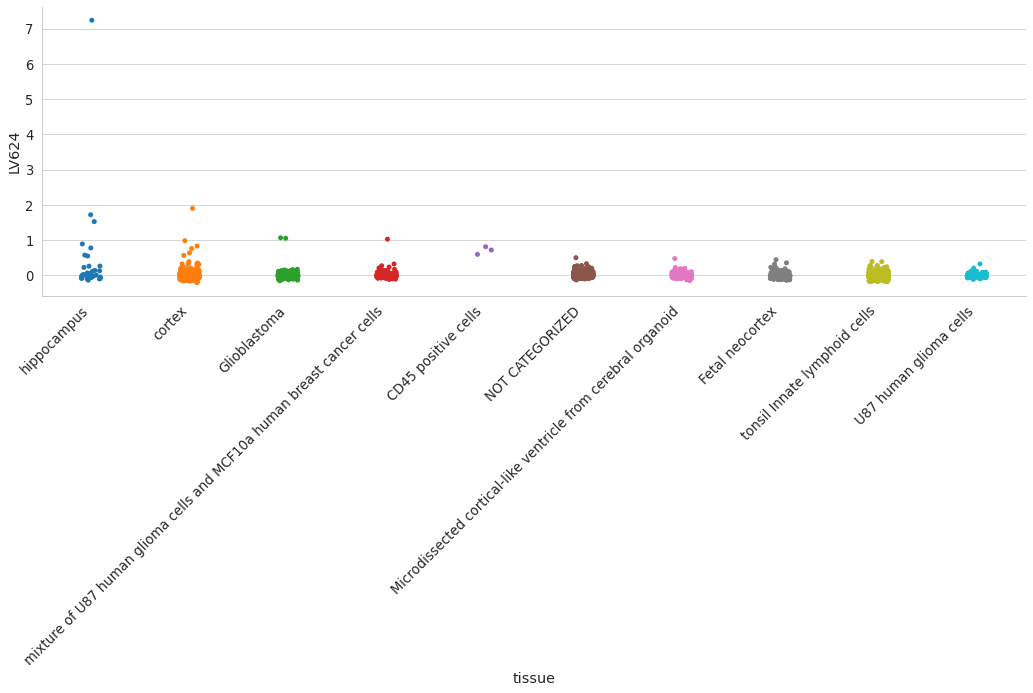

In [38]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

#     plt.savefig(
#         OUTPUT_CELL_TYPE_FILEPATH,
#         bbox_inches="tight",
#         facecolor="white",
#     )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [39]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("microglia")
    ]
    display(_tmp.head(20))

,,tissue,LV624
project,run,,


We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [40]:
# what is there in these projects?
lv_data.loc[["SRP057196"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

tissue          cell type                 age  \
project   run                                                              
SRP057196 SRR1974599  hippocampus          microglia  postnatal 54 years   
          SRR1974794  hippocampus        endothelial  postnatal 63 years   
          SRR1974774       cortex        endothelial  postnatal 63 years   
          SRR1974758       cortex        endothelial  postnatal 63 years   
          SRR1974865       cortex         astrocytes  postnatal 47 years   
          SRR1974598  hippocampus          microglia  postnatal 54 years   
          SRR1974969       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974962       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974591  hippocampus          microglia  postnatal 54 years   
          SRR1974669       cortex          microglia  postnatal 63 years   
          SRR1974585  hippocampus                OPC  postnatal 54 years   
          SRR1974876       cortex  fetal_replicating    prenatal 16-18 W   
          SRR1974560       cortex             hybrid  postnatal 54 years   
          SRR1974963       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974671       cortex          microglia  postnatal 63 years   
          SRR1974569       cortex             hybrid  postnatal 54 years   
          SRR1974992       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974871       cortex         astrocytes  postnatal 47 years   
          SRR1975002       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974968       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974690       cortex   oligodendrocytes  postnatal 50 years   
          SRR1974666       cortex          microglia  postnatal 47 years   
          SRR1974901       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974982       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974860       cortex          microglia  postnatal 47 years   
          SRR1974966       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974606       cortex          microglia  postnatal 37 years   
          SRR1974974       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974850       cortex             hybrid  postnatal 21 years   
          SRR1974933       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974932       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974667       cortex        endothelial  postnatal 47 years   
          SRR1974886       cortex  fetal_replicating    prenatal 16-18 W   
          SRR1974733       cortex         astrocytes  postnatal 50 years   
          SRR1974765       cortex   oligodendrocytes  postnatal 63 years   
          SRR1974594  hippocampus                OPC  postnatal 54 years   
          SRR1974760       cortex   oligodendrocytes  postnatal 63 years   
          SRR1974588  hippocampus                OPC  postnatal 54 years   
          SRR1974781       cortex        endothelial  postnatal 63 years   
          SRR1974782       cortex            neurons  postnatal 63 years   
          SRR1974582  hippocampus          microglia  postnatal 54 years   
          SRR1974919       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974768       cortex        endothelial  postnatal 63 years   
          SRR1974561       cortex   oligodendrocytes  postnatal 54 years   
          SRR1974943       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974563       cortex   oligodendrocytes  postnatal 54 years   
          SRR1974804       cortex             hybrid  postnatal 21 years   
          SRR1974595  hippocampus          microglia  postnatal 54 years   
          SRR1974771       cortex        endothelial  postnatal 63 years   
          SRR1974998       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974689       cortex         astrocytes  postnatal 50 years   

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.